In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.path.append('..')

from src.data_loader import download_all_assets
from src.preprocessing import clean_all_data,save_processed_data  #save_assets_to_csv
from src.feature_engineering import add_features_all
from src.stats_analysis import (summary_statistics_all,detect_outliers,
                           adf_test,calculate_var,calculate_sharpe_ratio,
                             adf_test)
from src.visualization import plot_closing_prices, plot_close_price,plot_daily_return
from src.risk_metrics import calculate_metrics_all


'''from statistics import (
    summary_statistics,
    adf_test,
    detect_outliers
)'''
'''from risk_metrics import (
    calculate_var,
    calculate_sharpe_ratio
)'''
'''from visualization import (
    plot_closing_prices,
    plot_daily_returns,
    plot_rolling_volatility)'''

'from visualization import (\n    plot_closing_prices,\n    plot_daily_returns,\n    plot_rolling_volatility)'

In [2]:
assets = download_all_assets()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
assets.keys()

dict_keys(['TSLA', 'BND', 'SPY'])

In [4]:
for ticker, df in assets.items():

    print("="*60)

    print(ticker)

    display(df.head())

TSLA


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500


BND


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,BND,BND,BND,BND,BND,BND
Date,,,,,,
2015-01-02,59.205681,82.650002,82.690002,82.419998,82.430000,2218800
2015-01-05,59.377621,82.889999,82.919998,82.699997,82.739998,5820100
2015-01-06,59.549507,83.129997,83.379997,83.029999,83.029999,3887600
2015-01-07,59.585339,83.180000,83.279999,83.050003,83.139999,2433400
2015-01-08,59.492203,83.050003,83.110001,82.970001,83.110001,1873400


SPY


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2015-01-02,169.687851,205.429993,206.880005,204.179993,206.380005,121465900
2015-01-05,166.623367,201.720001,204.369995,201.350006,204.169998,169632600
2015-01-06,165.053940,199.820007,202.720001,198.860001,202.089996,209151400
2015-01-07,167.110641,202.309998,202.720001,200.880005,201.419998,125346700
2015-01-08,170.076080,205.899994,206.160004,203.990005,204.009995,147217800


In [5]:
assets = clean_all_data(assets)

In [6]:
assets = add_features_all(assets)

In [7]:
stats = summary_statistics_all(assets)

stats["TSLA"]

Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean_20,Rolling_STD_20,Close_Scaled
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03,2887.000000,2869.000000,2869.000000,2888.000000
mean,148.773923,148.773923,151.990563,145.416731,148.797341,1.087922e+08,0.001803,148.406736,9.152835,0.289809
std,138.895957,138.895957,141.852818,135.867193,138.977191,7.082549e+07,0.036018,137.783817,9.959164,0.289185
min,9.578000,9.578000,10.331333,9.403333,9.488000,1.062000e+07,-0.210628,11.276033,0.194925,0.000000
25%,18.393499,18.393499,18.665168,18.023666,18.390833,6.548325e+07,-0.016643,18.686000,0.829353,0.018354
50%,133.437668,133.437668,136.053329,125.831669,131.496330,9.033615e+07,0.001216,136.818999,6.064276,0.257879
75%,251.925831,251.925831,257.485008,245.832500,251.680004,1.261204e+08,0.019456,251.276000,14.629171,0.504574
max,489.880005,489.880005,498.829987,485.329987,489.880005,9.140820e+08,0.226900,464.700502,53.380066,1.000000


In [8]:
stats["BND"]

Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean_20,Rolling_STD_20,Close_Scaled
Ticker,BND,BND,BND,BND,BND,BND,BND,BND,BND,BND
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03,2887.000000,2869.000000,2869.000000,2888.000000
mean,66.281146,79.327722,79.442119,79.211198,79.330661,4.653786e+06,-0.000034,79.334449,0.375409,0.526479
std,4.700143,5.310424,5.298010,5.322546,5.313805,3.017704e+06,0.003383,5.293372,0.257761,0.247688
min,58.531731,68.040001,68.379997,67.989998,68.080002,0.000000e+00,-0.054385,68.826500,0.089576,0.000000
25%,62.267982,73.800003,73.919998,73.639999,73.800003,2.233700e+06,-0.001635,73.735001,0.215184,0.268657
50%,65.507393,80.814999,80.905003,80.709999,80.800003,4.280650e+06,0.000119,80.823500,0.309002,0.595849
75%,70.451468,83.440002,83.550003,83.332500,83.470001,6.246475e+06,0.001715,83.458500,0.455840,0.718284
max,74.581299,89.480003,89.589996,89.440002,89.550003,3.396300e+07,0.042201,89.164000,2.452904,1.000000


In [9]:
stats["SPY"]

Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean_20,Rolling_STD_20,Close_Scaled
Ticker,SPY,SPY,SPY,SPY,SPY,SPY,SPY,SPY,SPY,SPY
count,2888.000000,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03,2887.000000,2869.000000,2869.000000,2888.000000
mean,351.505532,375.216714,377.167216,372.946586,375.149543,8.551049e+07,0.000507,374.581563,5.941019,0.333541
std,155.443934,146.584697,147.244714,145.774814,146.558911,4.338553e+07,0.011163,145.049866,4.315002,0.254174
min,154.161591,182.860001,184.100006,181.020004,182.339996,2.027000e+07,-0.109424,188.390000,0.529059,0.000000
25%,223.546799,254.559998,255.919998,252.477497,254.577503,5.836455e+07,-0.003772,255.713496,2.890942,0.124326
50%,312.817917,339.435013,342.315002,337.165009,339.835007,7.541950e+07,0.000603,341.533003,5.013278,0.271497
75%,432.806801,453.677498,456.000000,451.549988,453.989990,9.882245e+07,0.005920,450.087001,7.660182,0.469590
max,757.618225,759.570007,760.400024,756.750000,758.150024,5.072443e+08,0.105019,747.161002,30.867924,1.000000


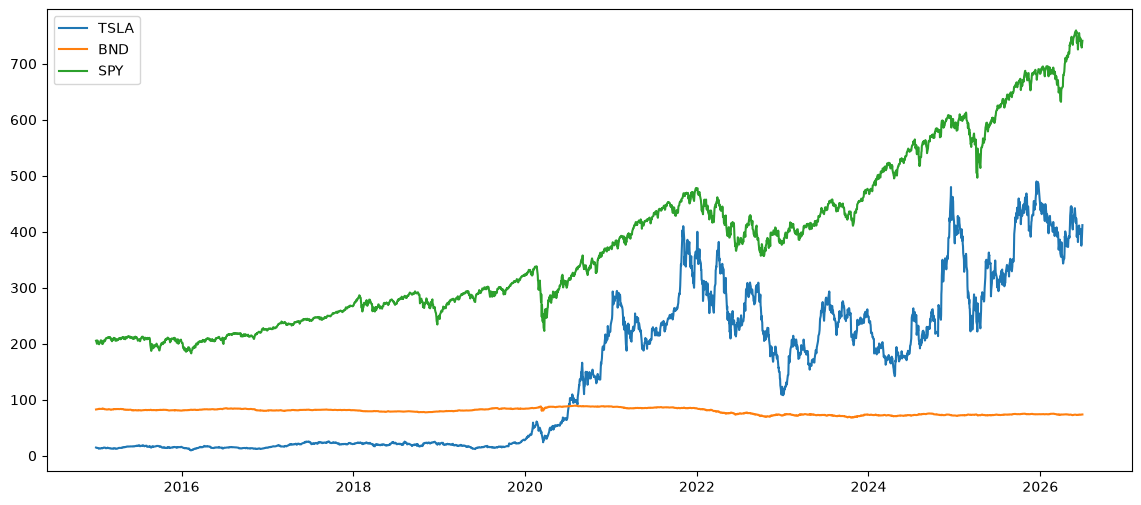

In [10]:
plot_closing_prices(assets)

In [11]:
risk_stats = calculate_metrics_all(assets)
print(risk_stats)

{'TSLA': {'VaR': np.float64(-0.051663755152845575), 'Sharpe': Ticker
TSLA    0.794437
dtype: float64}, 'BND': {'VaR': np.float64(-0.005084862828803238), 'Sharpe': Ticker
BND   -0.159185
dtype: float64}, 'SPY': {'VaR': np.float64(-0.016740570438910946), 'Sharpe': Ticker
SPY    0.720892
dtype: float64}}


In [12]:
detect_outliers(assets["TSLA"])

Price,Adj Close,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean_20,Rolling_STD_20,Close_Scaled
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500.0,0.005664,NaN,NaN,0.009384
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000.0,-0.001562,NaN,NaN,0.009339
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500.0,-0.001564,NaN,NaN,0.009293
...,...,...,...,...,...,...,...,...,...,...
2026-06-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-06-24,375.529999,375.529999,384.579987,373.049988,380.079987,37081400.0,-0.015932,407.934499,18.940312,0.761921


In [13]:
adf_test(assets["TSLA"]["Close"])

ADF Statistic : -1.069599
p-value       : 0.727042
Lags Used     : 27
Observations  : 2860

Critical Values
1%: -3.4326
5%: -2.8626
10%: -2.5673

Conclusion:
The series is Non-Stationary (Fail to Reject H0).


{'ADF Statistic': np.float64(-1.0695991394177442),
 'p-value': np.float64(0.7270419411549228),
 'Lags Used': 27,
 'Number of Observations': 2860,
 'Critical Values': {'1%': np.float64(-3.432638524105552),
  '5%': np.float64(-2.8625511137463935),
  '10%': np.float64(-2.567308245513228)}}

In [14]:
calculate_var(assets["TSLA"])

np.float64(-0.051663755152845575)

In [15]:
calculate_sharpe_ratio(assets["TSLA"])

Ticker
TSLA    0.050045
dtype: float64

In [16]:
for ticker, df in assets.items():

    print("=" * 70)
    print(f"ADF Test : {ticker} Closing Price")

    result = adf_test(df["Close"])

ADF Test : TSLA Closing Price
ADF Statistic : -1.069599
p-value       : 0.727042
Lags Used     : 27
Observations  : 2860

Critical Values
1%: -3.4326
5%: -2.8626
10%: -2.5673

Conclusion:
The series is Non-Stationary (Fail to Reject H0).
ADF Test : BND Closing Price
ADF Statistic : -1.036180
p-value       : 0.739841
Lags Used     : 13
Observations  : 2874

Critical Values
1%: -3.4326
5%: -2.8625
10%: -2.5673

Conclusion:
The series is Non-Stationary (Fail to Reject H0).
ADF Test : SPY Closing Price
ADF Statistic : 0.991815
p-value       : 0.994179
Lags Used     : 9
Observations  : 2878

Critical Values
1%: -3.4326
5%: -2.8625
10%: -2.5673

Conclusion:
The series is Non-Stationary (Fail to Reject H0).


In [17]:
for ticker, df in assets.items():

    print("=" * 70)
    print(f"ADF Test : {ticker} Daily Return")

    result = adf_test(
        df["Daily_Return"]
    )

ADF Test : TSLA Daily Return
ADF Statistic : -53.971893
p-value       : 0.000000
Lags Used     : 0
Observations  : 2886

Critical Values
1%: -3.4326
5%: -2.8625
10%: -2.5673

Conclusion:
The series is Stationary (Reject H0).
ADF Test : BND Daily Return
ADF Statistic : -15.296417
p-value       : 0.000000
Lags Used     : 12
Observations  : 2874

Critical Values
1%: -3.4326
5%: -2.8625
10%: -2.5673

Conclusion:
The series is Stationary (Reject H0).
ADF Test : SPY Daily Return
ADF Statistic : -17.490538
p-value       : 0.000000
Lags Used     : 8
Observations  : 2878

Critical Values
1%: -3.4326
5%: -2.8625
10%: -2.5673

Conclusion:
The series is Stationary (Reject H0).


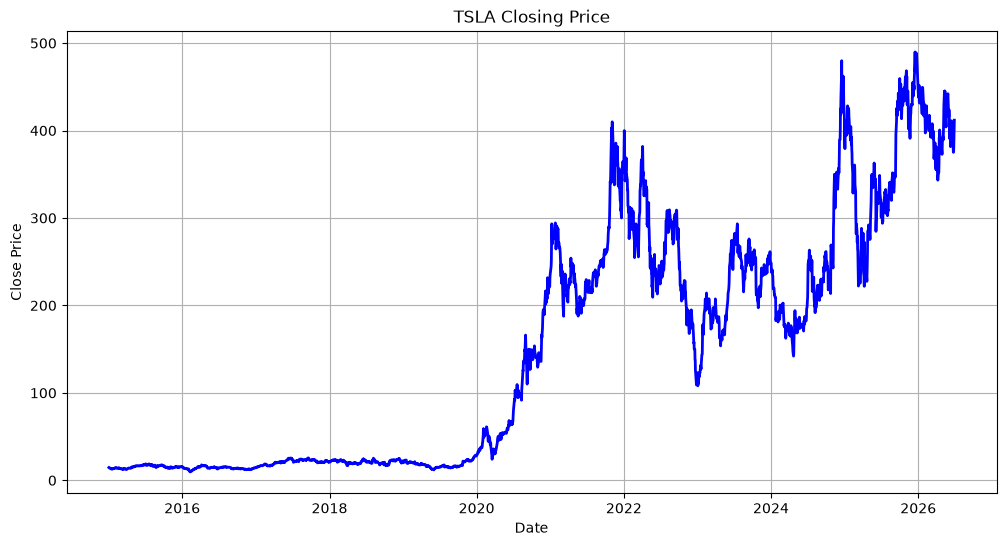

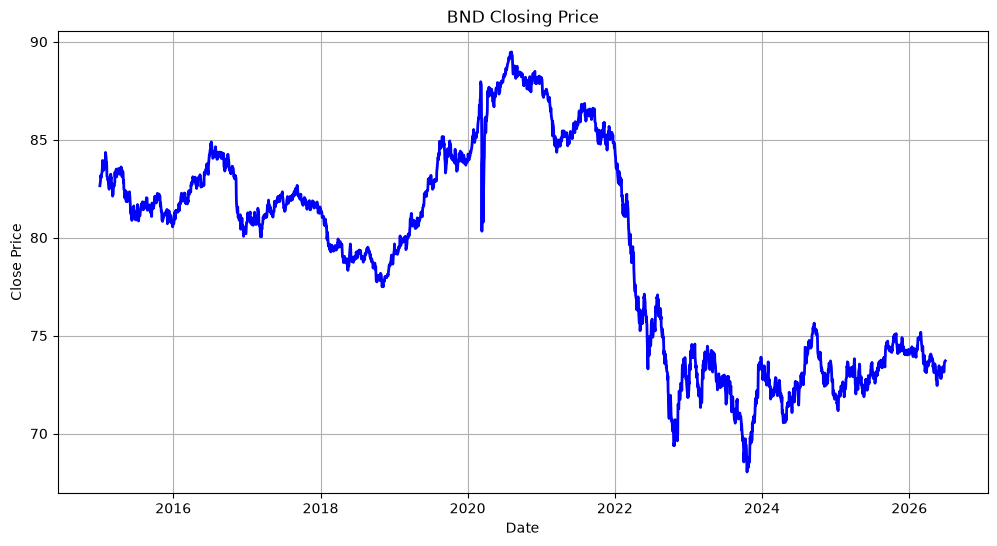

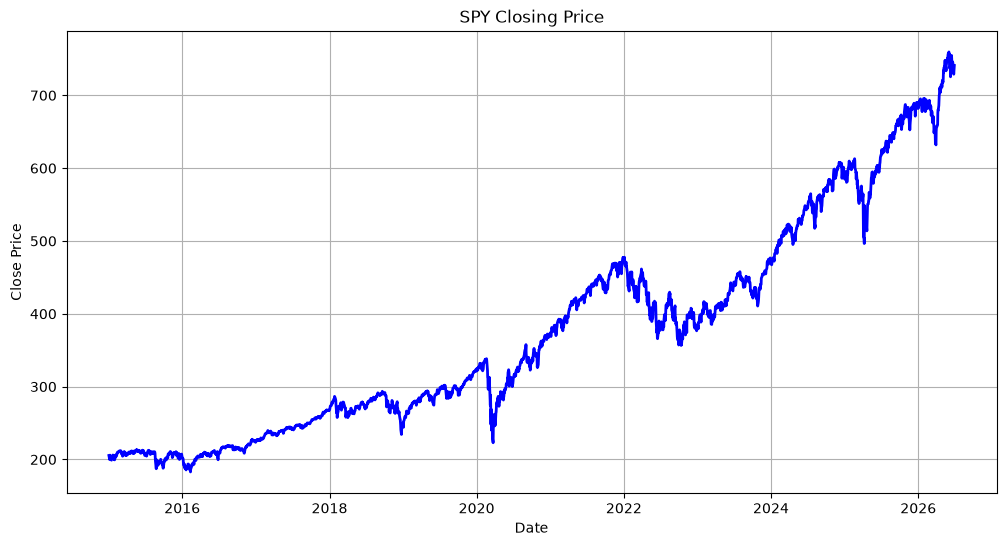

In [18]:
for ticker, df in assets.items():

    plot_close_price(df, ticker)

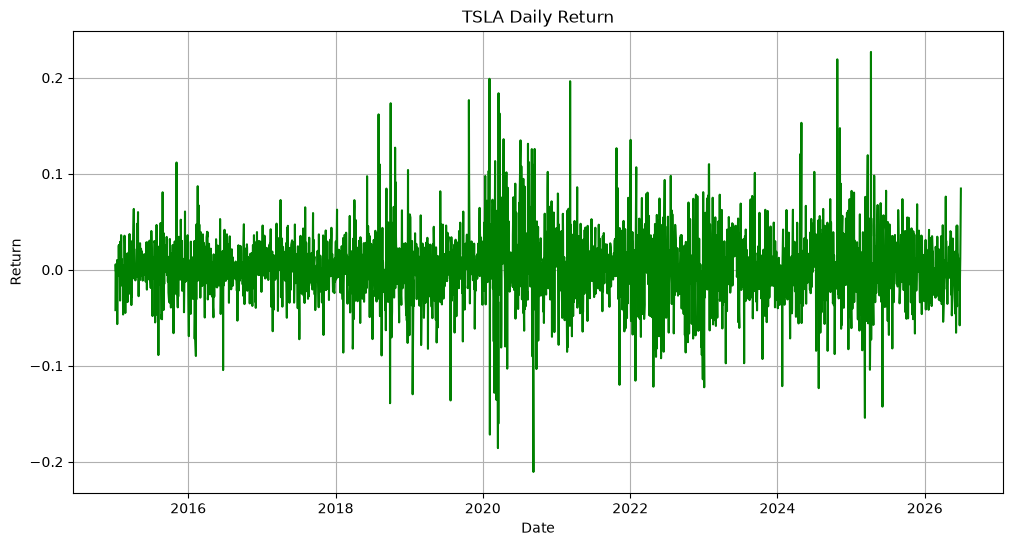

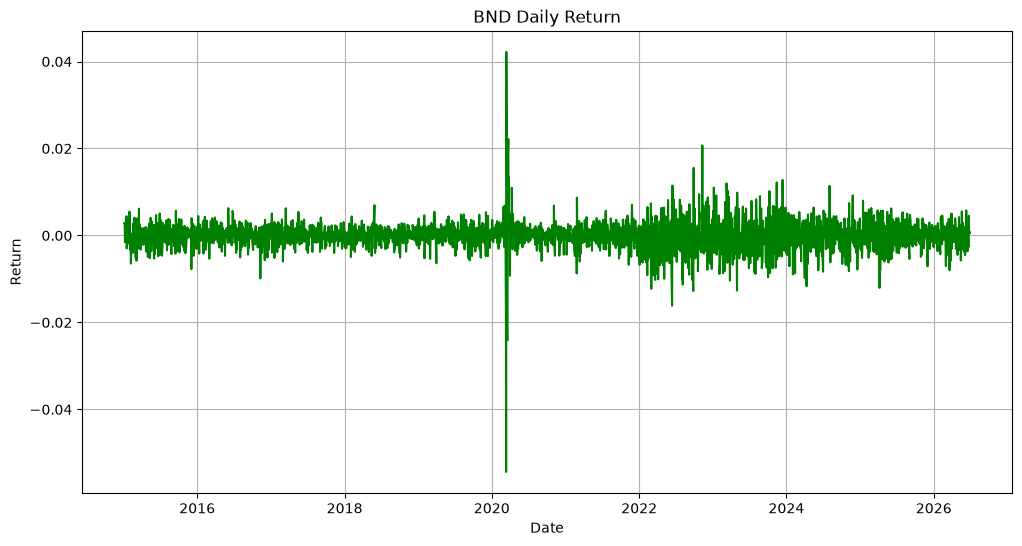

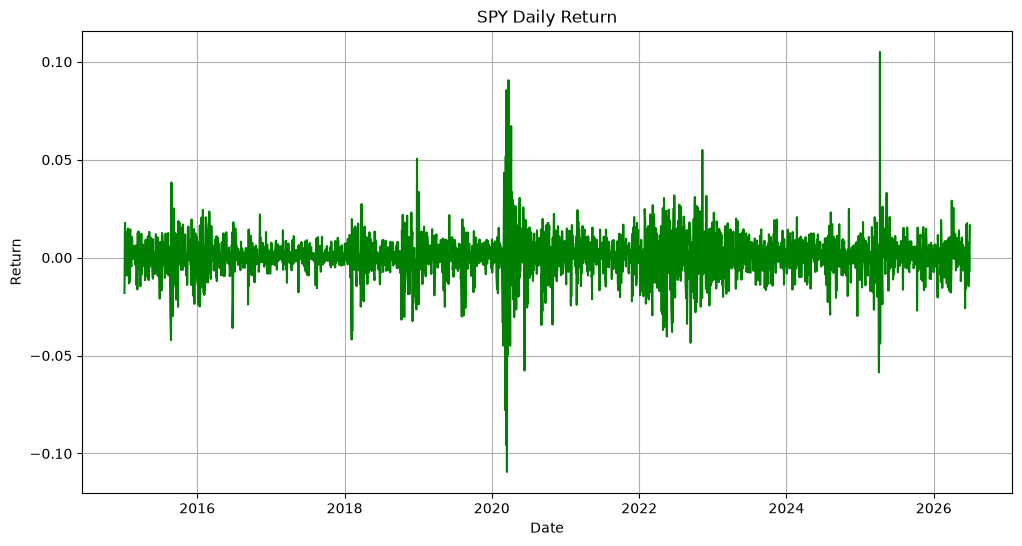

In [19]:
for ticker, df in assets.items():

    plot_daily_return(df, ticker)

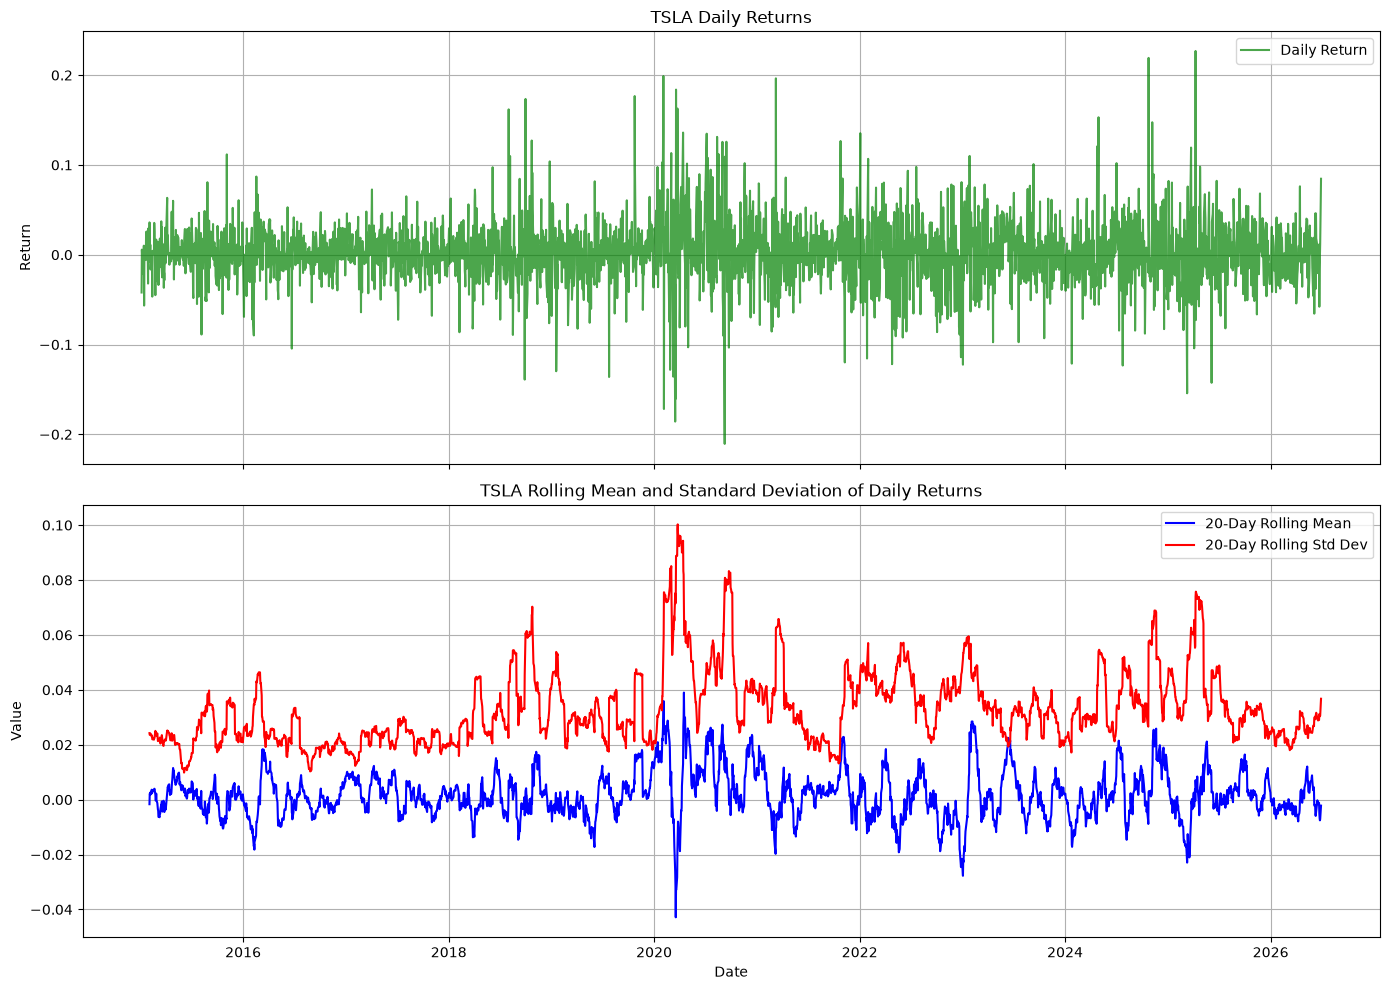

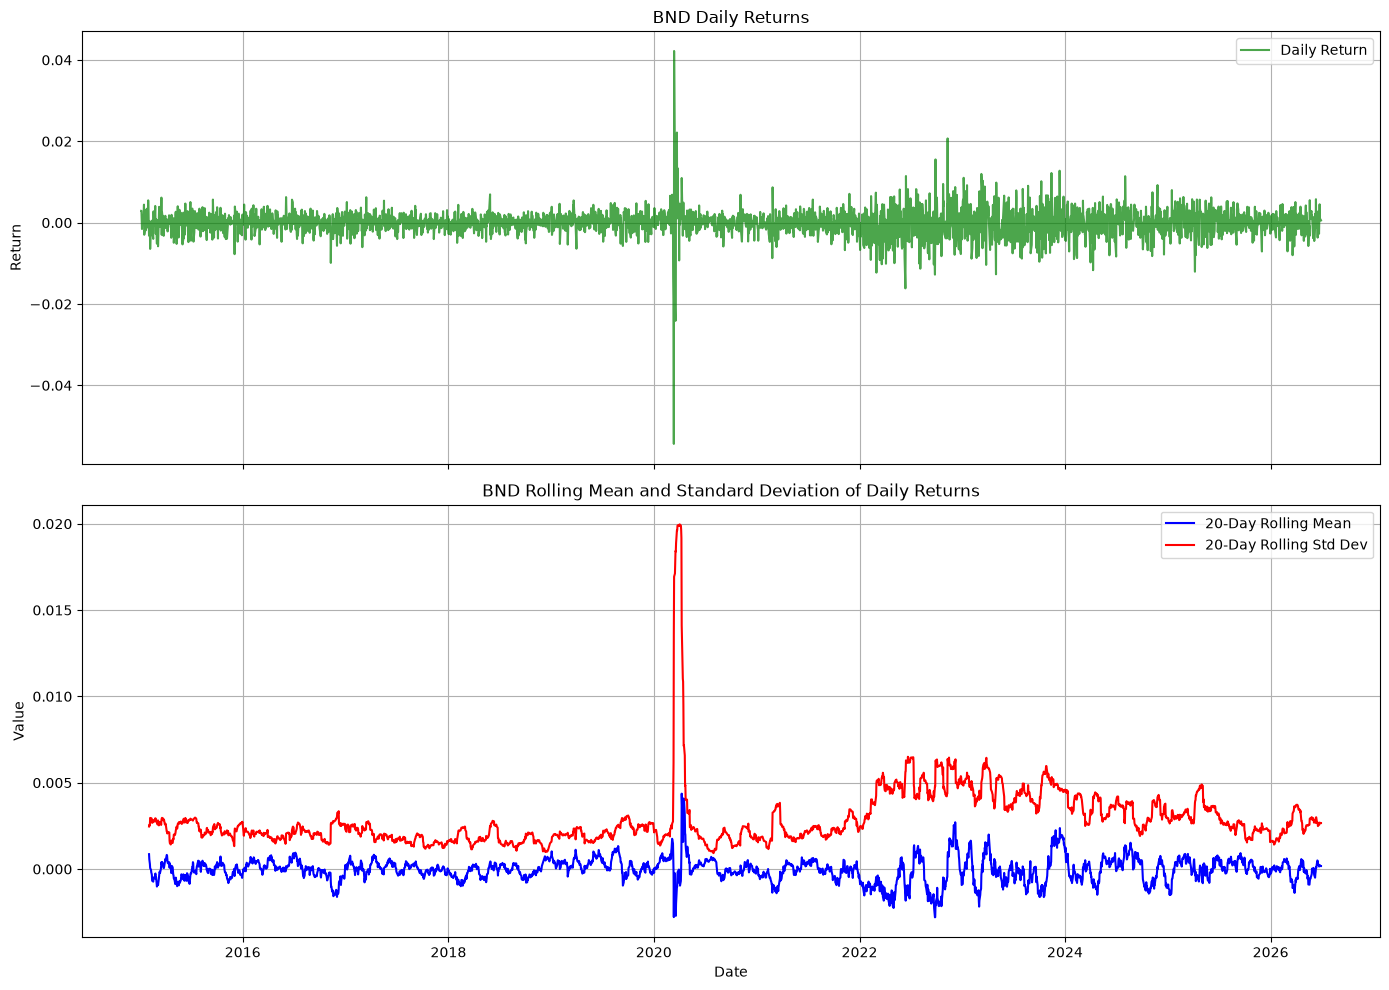

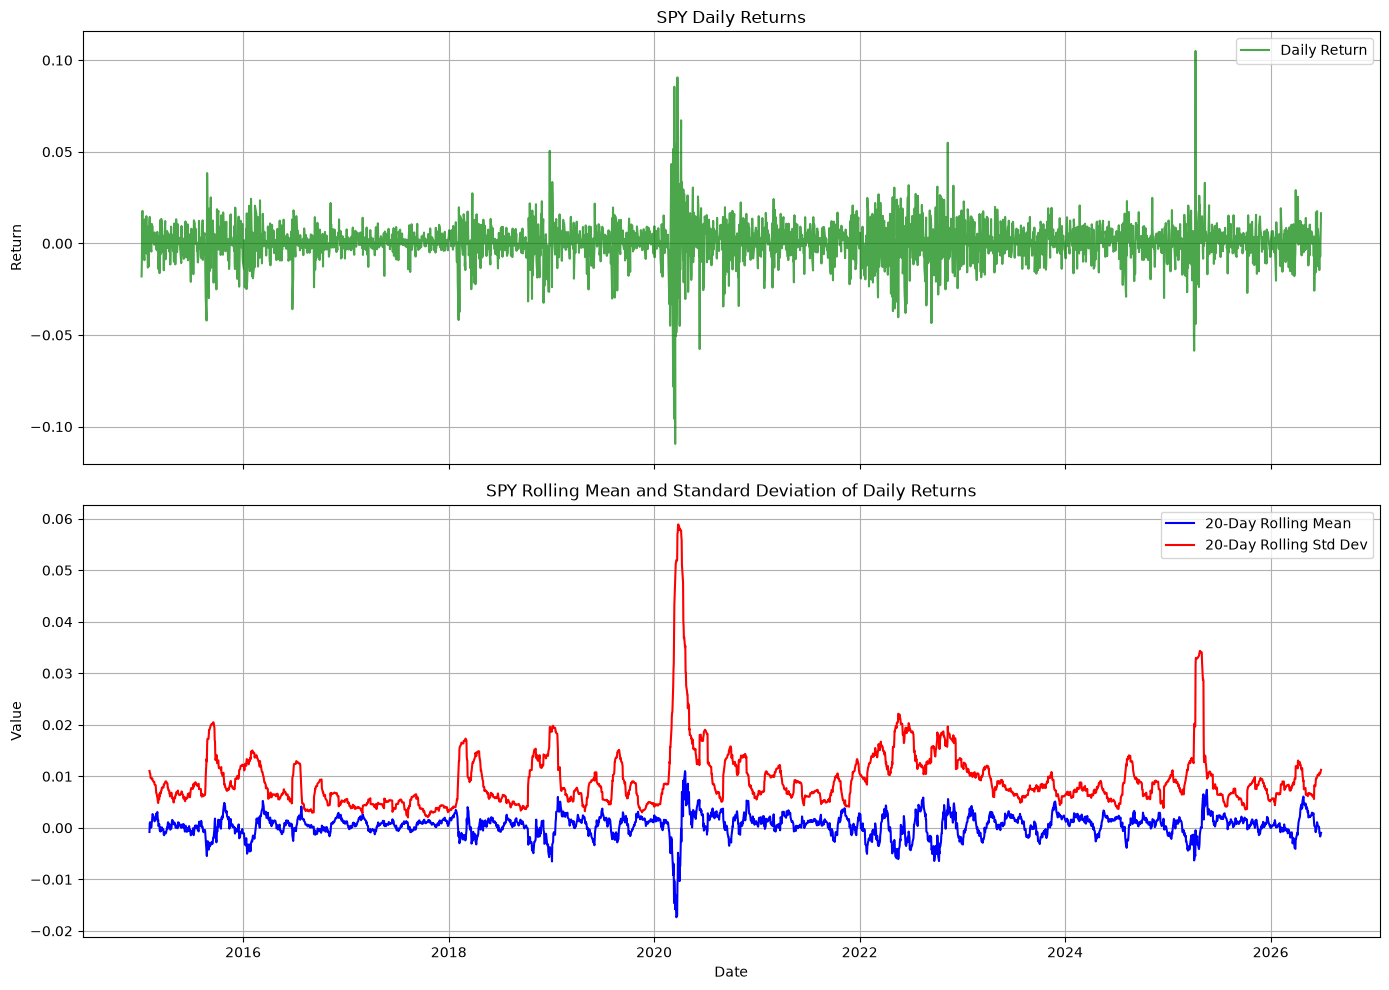

In [20]:
import matplotlib.pyplot as plt

for ticker, df in assets.items():
    # Calculate rolling mean and standard deviation for 'Daily_Return'
    rolling_mean = df['Daily_Return'].rolling(window=20).mean()
    rolling_std = df['Daily_Return'].rolling(window=20).std()

    fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

    # Plot Daily Returns
    axes[0].plot(df.index, df['Daily_Return'], label='Daily Return', color='green', alpha=0.7)
    axes[0].set_title(f'{ticker} Daily Returns')
    axes[0].set_ylabel('Return')
    axes[0].grid(True)
    axes[0].legend()

    # Plot Rolling Statistics
    axes[1].plot(df.index, rolling_mean, label='20-Day Rolling Mean', color='blue')
    axes[1].plot(df.index, rolling_std, label='20-Day Rolling Std Dev', color='red')
    axes[1].set_title(f'{ticker} Rolling Mean and Standard Deviation of Daily Returns')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Value')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [21]:
for ticker, df in assets.items():
    print("=" * 70)
    print(f"Analyzing extreme daily returns for {ticker}")

    # Calculate mean and standard deviation of daily returns
    # Access 'Daily_Return' using the correct MultiIndex tuple (feature_name, ticker_symbol)
    daily_returns_col = ('Daily_Return', ticker)
    mean_return = df[daily_returns_col].mean()
    std_return = df[daily_returns_col].std()

    # Define thresholds (e.g., 3 standard deviations)
    upper_threshold = mean_return + 3 * std_return
    lower_threshold = mean_return - 3 * std_return

    # Identify days with unusually high returns
    high_returns = df[df[daily_returns_col] > upper_threshold]
    print(f"\nDays with unusually HIGH returns for {ticker}:")
    if not high_returns.empty:
        display(high_returns[[daily_returns_col]].sort_values(by=daily_returns_col, ascending=False))
    else:
        print("No unusually high returns found.")

    # Identify days with unusually low returns
    low_returns = df[df[daily_returns_col] < lower_threshold]
    print(f"\nDays with unusually LOW returns for {ticker}:")
    if not low_returns.empty:
        display(low_returns[[daily_returns_col]].sort_values(by=daily_returns_col, ascending=True))
    else:
        print("No unusually low returns found.")

    print("=" * 70)

Analyzing extreme daily returns for TSLA

Days with unusually HIGH returns for TSLA:


Price,Daily_Return
Ticker,TSLA
Date,
2025-04-09,0.226900
2024-10-24,0.219190
2020-02-03,0.198949
2021-03-09,0.196412
2020-03-19,0.183877
2019-10-24,0.176692
2018-10-01,0.173471
2020-03-24,0.162817



Days with unusually LOW returns for TSLA:


Price,Daily_Return
Ticker,TSLA
Date,
2020-09-08,-0.210628
2020-03-16,-0.185778
2020-02-05,-0.171758
2020-03-18,-0.160344
2025-03-10,-0.154262
2025-06-05,-0.142599
2018-09-28,-0.139015
2019-07-25,-0.136137


Analyzing extreme daily returns for BND

Days with unusually HIGH returns for BND:


...

Price,Daily_Return
Ticker,BND
Date,
2020-03-12,-0.054385
2020-03-18,-0.024140
2020-03-17,-0.020686
2020-03-11,-0.018940
2022-06-13,-0.016153
2020-03-10,-0.013444
2022-09-26,-0.012778
2023-05-01,-0.012689


Analyzing extreme daily returns for SPY

Days with unusually HIGH returns for SPY:


Price,Daily_Return
Ticker,SPY
Date,
2025-04-09,0.105019
2020-03-24,0.090603
2020-03-13,0.085486
2020-04-06,0.067166
2020-03-26,0.058390
2022-11-10,0.054954
2020-03-17,0.053992
2020-03-10,0.051745



Days with unusually LOW returns for SPY:


Price,Daily_Return
Ticker,SPY
Date,
2020-03-16,-0.109424
2020-03-12,-0.095677
2020-03-09,-0.078094
2025-04-04,-0.058543
2020-06-11,-0.057649
2020-03-18,-0.050633
2025-04-03,-0.049281
2020-03-11,-0.048748


In [22]:
save_processed_data(assets)

All processed datasets have been saved successfully.


In [23]:
print(df.columns)


MultiIndex([(      'Adj Close', 'SPY'),
            (          'Close', 'SPY'),
            (           'High', 'SPY'),
            (            'Low', 'SPY'),
            (           'Open', 'SPY'),
            (         'Volume', 'SPY'),
            (   'Daily_Return', 'SPY'),
            ('Rolling_Mean_20', 'SPY'),
            ( 'Rolling_STD_20', 'SPY'),
            (   'Close_Scaled', 'SPY')],
           names=['Price', 'Ticker'])


Based on the exploratory data analysis and risk metric calculations, several key patterns and insights emerge for TSLA, BND, and SPY:

Overall Direction and Volatility (Closing Prices & Daily Returns):

TSLA: Exhibits significant growth over the period, but with very high volatility, particularly noticeable in its daily returns. The Close_Scaled shows its rapid increase relative to others.
BND: Represents a bond ETF, showing far less volatility and a relatively stable, though slightly declining, trend compared to the equities. Its daily returns are much tighter around zero.
SPY: As an S&P 500 ETF, it shows a general upward trend, indicative of overall market growth, with moderate volatility that is higher than BND but lower than TSLA.
Volatility Analysis (Rolling Statistics):

All assets show periods of increased rolling standard deviation (volatility), particularly during major market events (e.g., early 2020). TSLA consistently shows higher levels of rolling volatility compared to BND and SPY, aligning with its growth stock nature.
Outlier Detection:

Extreme daily returns were observed for all assets, particularly TSLA and SPY, often corresponding to significant news events or market shocks. These outliers highlight the episodic nature of high-impact events in financial markets. BND also showed outliers, though less frequently and with smaller magnitudes, usually during periods of market stress.
Stationarity:

As confirmed by the ADF tests, all raw closing price series are non-stationary, underscoring the need for transformations (like differencing to daily returns) for many time-series models. Conversely, the daily return series for all assets are stationary, making them suitable for direct application in models that assume stationarity.
Risk Metrics (VaR & Sharpe Ratio):

Value at Risk (VaR): TSLA has the highest VaR (most negative), indicating a higher potential for loss on a given day compared to BND and SPY. BND, as expected, has the lowest (least negative) VaR, reflecting its lower risk profile. SPY falls in between.
Sharpe Ratio: TSLA and SPY generally show positive Sharpe Ratios, suggesting that, on average, they have provided good risk-adjusted returns over the period. BND's Sharpe Ratio is slightly negative, indicating that its returns have not adequately compensated for its (albeit lower) risk, possibly due to a rising interest rate environment or specific bond market conditions over the period.
In summary, TSLA is characterized by high growth and high risk/volatility, SPY by moderate growth and moderate risk, and BND by low growth and low risk, consistent with their asset classes. The data is well-prepared for further modeling, with the understanding that daily returns provide a stationary series suitable for forecasting.